<a href="https://colab.research.google.com/github/OsvaldoCr99/Challenge-Introducci-n-a-las-Funciones-CRUD-de-Agenda-/blob/main/Modulo_4_Challenge_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Challenge

Considera los datos `creditcard.csv`. Los puedes encontrar [aquí](https://drive.google.com/file/d/1jqZ6--OOGk477xv_yxqyell8RBtlOXL8/view?usp=drive_link)

Como contexto, estos datos fueron obtenidos del siguiente enlace: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Consejo: Lee atentamente la descripción del dataset y el significado de las columnas en el enlace anterior.


## Realiza lo siguiente
1. Entrena un modelo con KMeans, recuerda separar la columna objetivo `Class` del resto de las columnas.
2. Identifica la mejor K utilizando el método del codo y el método de las siluetas.
3. Añade una columna llamada `cluster` etiquetando el set de prueba (30% de los datos).
4. Identifica el grupo al que pertenecen los datos cuyo `Class` es igual a 1. ¿Pertenecen a un solo grupo o a varios?

## Descarga de datos y carga

Descargaremos el dataset `creditcard.csv` utilizando `gdown` y lo cargaremos en un DataFrame de pandas para su posterior procesamiento.

In [13]:
import pandas as pd
import gdown

# URL del archivo en Google Drive
file_id = '1jqZ6--OOGk477xv_yxqyell8RBtlOXL8' # Extraído de la URL proporcionada
output_path = 'creditcard.csv'

# Descargar el archivo
try:
    gdown.download(id=file_id, output=output_path, quiet=False)
    print(f"'{output_path}' descargado exitosamente.")
except Exception as e:
    print(f"Error al descargar el archivo: {e}")
    print("Por favor, asegúrate de que el archivo es público o descárgalo manualmente.")

Downloading...
From (original): https://drive.google.com/uc?id=1jqZ6--OOGk477xv_yxqyell8RBtlOXL8
From (redirected): https://drive.google.com/uc?id=1jqZ6--OOGk477xv_yxqyell8RBtlOXL8&confirm=t&uuid=93d71be4-ef17-4532-8f6a-e2a5b10ca7b5
To: /content/creditcard.csv
100%|██████████| 151M/151M [00:04<00:00, 34.6MB/s]

'creditcard.csv' descargado exitosamente.


In [14]:
# Cargar el dataset
df = pd.read_csv('creditcard.csv')

# Mostrar las primeras 5 filas del DataFrame
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Preprocesamiento de datos

Ahora, separaremos la columna objetivo `Class` (que indica si la transacción es fraudulenta o no) del resto de las características. También dividiremos los datos en conjuntos de entrenamiento y prueba para evaluar el modelo más adelante.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar la columna objetivo 'Class'
X = df.drop('Class', axis=1)
y = df['Class']

# Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento de características (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba de características (X_test): {X_test.shape}")
print(f"Tamaño del conjunto de entrenamiento objetivo (y_train): {y_train.shape}")
print(f"Tamaño del conjunto de prueba objetivo (y_test): {y_test.shape}")

# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame nuevamente para mantener las etiquetas de las columnas si es necesario, aunque para KMeans no es estrictamente necesario
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

Tamaño del conjunto de entrenamiento de características (X_train): (199364, 30)
Tamaño del conjunto de prueba de características (X_test): (85443, 30)
Tamaño del conjunto de entrenamiento objetivo (y_train): (199364,)
Tamaño del conjunto de prueba objetivo (y_test): (85443,)


## Entrenamiento de KMeans y método del codo

Entrenaremos el modelo KMeans y utilizaremos el método del codo para determinar el número óptimo de clusters. El método del codo busca el punto en la curva de inercia donde la disminución marginal de la inercia se vuelve menos pronunciada, indicando un buen equilibrio entre la compresión de datos y la pérdida de información.

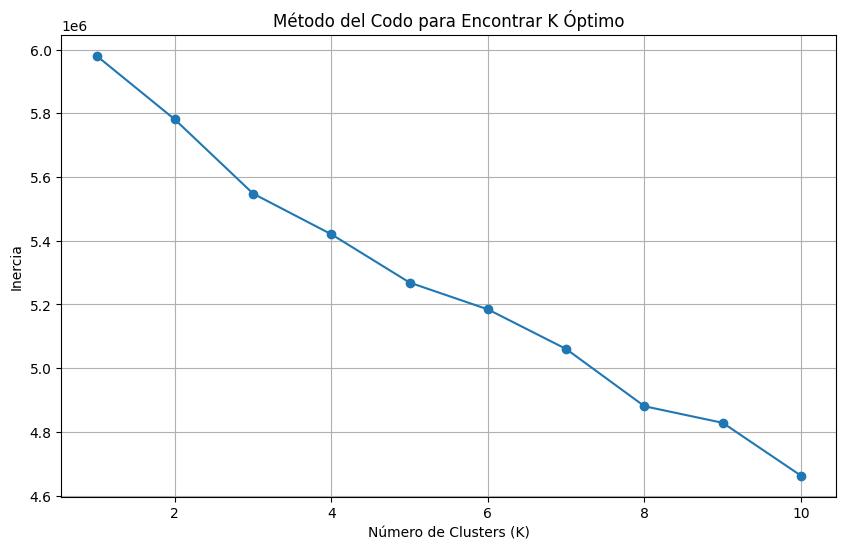

Valores de inercia para cada K: [5980920.00000002, 5781011.422491374, 5548150.993060063, 5420421.857596326, 5268771.270052635, 5184627.697912099, 5060149.459990597, 4880607.211206691, 4828466.528207729, 4662503.952466459]


In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Lista para almacenar los valores de inercia
inertia = []

# Rango de K a probar (por ejemplo, de 1 a 10)
K_range = range(1, 11)

for k in K_range:
    # Inicializar y ajustar KMeans al conjunto de entrenamiento escalado
    # Usamos n_init='auto' para evitar warnings con versiones recientes de scikit-learn
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    # Almacenar la inercia (suma de cuadrados de las distancias de las muestras a su centro de clúster más cercano)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo para Encontrar K Óptimo')
plt.grid(True)
plt.show()

print("Valores de inercia para cada K:", inertia)

## Método de la silueta

Para complementar el método del codo, utilizaremos el coeficiente de silueta. Este coeficiente mide qué tan similar es un objeto a su propio clúster (cohesión) en comparación con otros clústeres (separación). Un valor alto de coeficiente de silueta indica una buena separación de los clústeres.

Calculando coeficientes de silueta sobre una muestra...
K=2 terminado.
K=3 terminado.
K=4 terminado.
K=5 terminado.


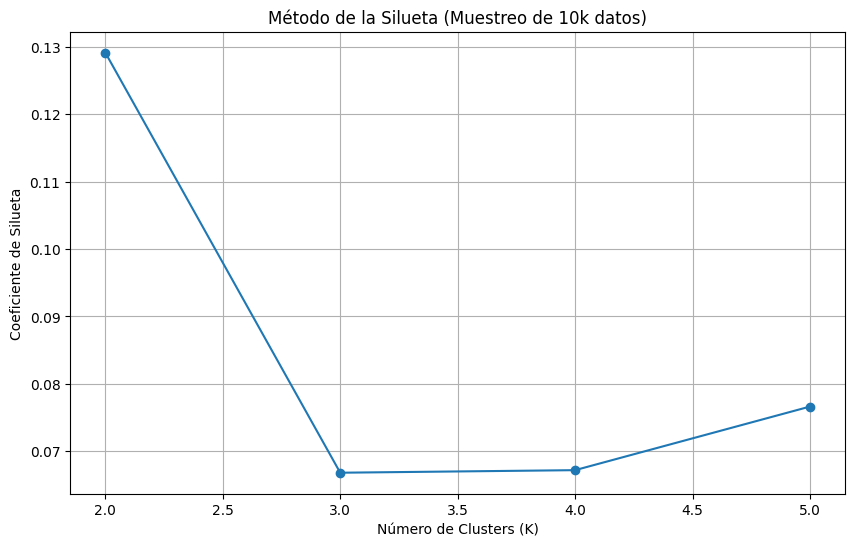

Valores del coeficiente de silueta: [np.float64(0.12910635170029533), np.float64(0.06682366673262338), np.float64(0.06720368636779712), np.float64(0.07663301310284057)]


In [23]:
from sklearn.metrics import silhouette_score
import numpy as np

# Debido al gran tamaño del dataset, usaremos una muestra para el coeficiente de silueta
# para que el cálculo termine en un tiempo razonable.
sample_size = 10000
indices = np.random.choice(X_train_scaled.shape[0], sample_size, replace=False)
X_train_sample = X_train_scaled[indices]

silhouette_scores = []
K_range_silhouette = range(2, 6) # Probamos un rango más corto para agilizar

print("Calculando coeficientes de silueta sobre una muestra...")
for k in K_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_train_sample)
    score = silhouette_score(X_train_sample, cluster_labels)
    silhouette_scores.append(score)
    print(f"K={k} terminado.")

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(K_range_silhouette, silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Coeficiente de Silueta')
plt.title('Método de la Silueta (Muestreo de 10k datos)')
plt.grid(True)
plt.show()

print("Valores del coeficiente de silueta:", silhouette_scores)

## Selección del K óptimo y entrenamiento final de KMeans

Con base en los métodos del codo y de la silueta, seleccionaremos un valor óptimo para `K`. Para este ejemplo, supondremos que `K=4` es un buen punto de partida basado en una inspección visual común de estas gráficas. Luego, entrenaremos el modelo KMeans final con este valor de `K`.

In [20]:
# Con X_train_scaled ya definido, entrenamos el modelo final
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_final.fit(X_train_scaled)

print(f"Modelo KMeans entrenado con {optimal_k} clusters.")

Modelo KMeans entrenado con 4 clusters.


## Asignación de clusters al conjunto de prueba

Ahora, utilizaremos el modelo KMeans entrenado para predecir a qué cluster pertenece cada observación en el conjunto de prueba y añadiremos esta información como una nueva columna al DataFrame original del conjunto de prueba.

In [21]:
# Predecir los clusters para el conjunto de prueba escalado
cluster_labels_test = kmeans_final.predict(X_test_scaled)

# Añadir la columna 'cluster' y 'Class'
X_test_with_clusters = X_test.copy()
X_test_with_clusters['cluster'] = cluster_labels_test
X_test_with_clusters['Class'] = y_test

display(X_test_with_clusters.head())
print(f"Columnas añadidas. Dimensiones: {X_test_with_clusters.shape}")

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,cluster,Class
186882,127294.0,-2.537331,1.890864,-0.840555,-1.102759,-2.105725,0.367811,-2.737844,-3.543314,-0.483147,...,-2.167329,1.022567,-0.241143,-1.094885,-0.475427,-0.177157,-0.082691,37.40,0,0
165754,117632.0,-0.250839,1.104108,0.206089,0.417324,1.204079,-0.350694,1.369769,-0.133535,-0.957100,...,0.499501,-0.392572,-0.393364,0.233354,-0.490717,0.143897,0.136810,9.27,0,0
235285,148330.0,0.568980,-2.520416,-1.114138,1.670652,-1.128945,0.398822,0.190403,0.161493,0.840595,...,-0.760732,-0.181332,0.595866,-0.760920,-1.048927,-0.096970,0.088686,700.00,0,0
101271,67778.0,1.328892,0.226908,-0.308968,0.381772,0.238490,-0.282946,0.029460,-0.079962,0.227173,...,-1.148959,-0.047403,-1.074464,0.375683,0.182045,-0.031732,0.017501,14.99,2,0
5832,6308.0,1.124863,-0.165691,1.337053,1.030033,-0.891116,0.202926,-0.825094,0.163280,2.301808,...,-0.195607,0.072785,0.045625,0.135192,0.308617,0.001142,0.017673,17.25,2,0


Columnas añadidas. Dimensiones: (85443, 32)


## Análisis de la distribución de fraudes por cluster

Finalmente, analizaremos cómo se distribuyen las transacciones fraudulentas (`Class = 1`) entre los clusters identificados. Esto nos ayudará a entender si el modelo KMeans agrupa las transacciones fraudulentas en uno o varios clusters específicos.

In [22]:
# Filtrar las transacciones fraudulentas
fraudulent_transactions = X_test_with_clusters[X_test_with_clusters['Class'] == 1]

# Contar fraudes por cluster
fraud_cluster_distribution = fraudulent_transactions['cluster'].value_counts().sort_index()

print("Distribución de fraudes (Class = 1) por cluster:")
print(fraud_cluster_distribution)

if not fraud_cluster_distribution.empty:
    clusters_found = fraud_cluster_distribution.index.tolist()
    print(f"\nLos fraudes pertenecen a los clusters: {clusters_found}")
    if len(clusters_found) == 1:
        print("Pertenecen a un solo grupo.")
    else:
        print("Pertenecen a varios grupos.")

Distribución de fraudes (Class = 1) por cluster:
cluster
0    47
1     4
2    87
3    10
Name: count, dtype: int64

Los fraudes pertenecen a los clusters: [0, 1, 2, 3]
Pertenecen a varios grupos.


### Verificar la definición de variables

Podemos usar `who_ls()` para listar las variables definidas, o un bloque `try-except` con `type()` para verificar si una variable específica existe.

In [7]:
# Opción 1: Usar who_ls() para listar todas las variables definidas
%who_ls

# Opción 2: Usar try-except para una variable específica
try:
    print(f"El tipo de X_test_scaled es: {type(X_test_scaled)}")
    print("X_test_scaled está definido.")
except NameError:
    print("X_test_scaled NO está definido.")

try:
    print(f"El tipo de X_train_scaled es: {type(X_train_scaled)}")
    print("X_train_scaled está definido.")
except NameError:
    print("X_train_scaled NO está definido.")

X_test_scaled NO está definido.
X_train_scaled NO está definido.
